In [27]:
!pip install wfdb numpy scipy matplotlib -q

Loaded: fs=360 Hz, samples=650000, duration=30.1 min
Total beats detected: 2273
First RR interval: 0.814 sec
First HR value: 73.7 bpm
Mean HR: 75.8 bpm
HR range: 52.0 – 116.8 bpm


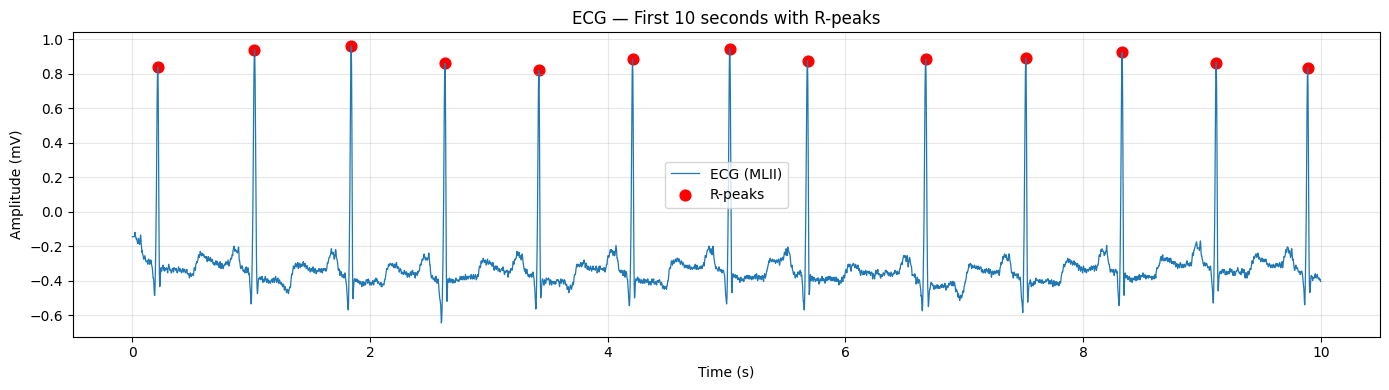

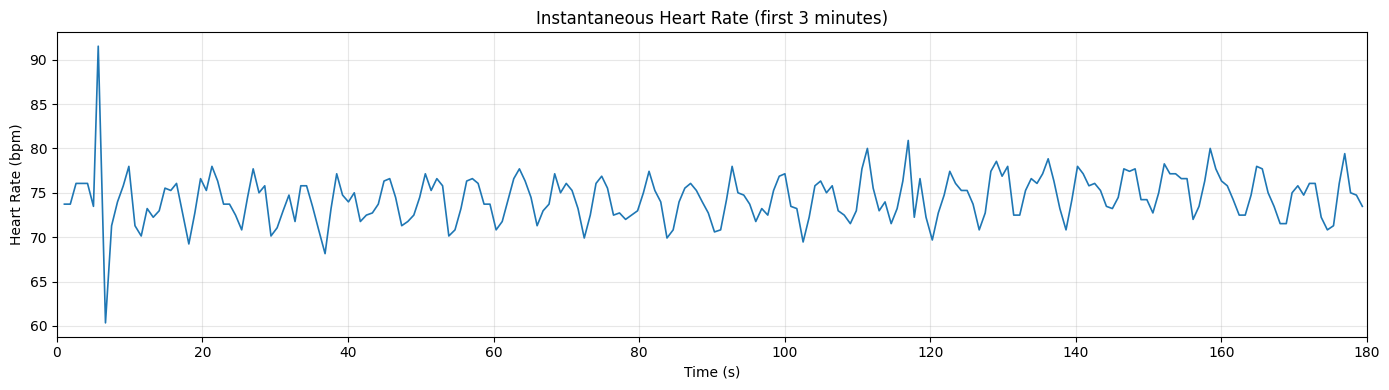

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import wfdb

# Load record
record = wfdb.rdrecord("/content/100")
fs     = record.fs
signal = record.p_signal[:, 0]  # MLII channel
t      = np.arange(len(signal)) / fs

print(f"Loaded: fs={fs} Hz, samples={len(signal)}, duration={len(signal)/fs/60:.1f} min")


# Bandpass filter (5–15 Hz)
def bandpass(sig, fs, lowcut=5.0, highcut=15.0, order=4):
    nyq = fs / 2.0
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return filtfilt(b, a, sig)

filtered = bandpass(signal, fs=fs)

# Pan-Tompkins-like preprocessing
# derivative → squaring → MWI
diff    = np.diff(filtered, prepend=filtered[0])
squared = diff ** 2

win_len = int(0.150 * fs)
window  = np.ones(win_len) / win_len
mwi     = np.convolve(squared, window, mode="same")

# R-peak detection on MWI
threshold    = 0.08 * np.max(mwi)
min_distance = int(0.250 * fs)

r_peaks, _ = find_peaks(mwi, height=threshold, distance=min_distance)

# Refinement on original ECG
# (±20 ms around each peak)
search_radius = int(0.020 * fs)

r_peaks_refined = []

for peak in r_peaks:
    start = max(0, peak - search_radius)
    end   = min(len(signal), peak + search_radius)

    local_segment = signal[start:end]
    refined_peak  = start + np.argmax(local_segment)
    r_peaks_refined.append(refined_peak)

r_peaks_refined = np.array(r_peaks_refined)

# Heart rate computation
rr_intervals = np.diff(r_peaks_refined) / fs
heart_rate   = 60.0 / rr_intervals
hr_times     = t[r_peaks_refined[1:]]

print(f"Total beats detected: {len(r_peaks_refined)}")
print(f"First RR interval: {rr_intervals[0]:.3f} sec")
print(f"First HR value: {heart_rate[0]:.1f} bpm")
print(f"Mean HR: {heart_rate.mean():.1f} bpm")
print(f"HR range: {heart_rate.min():.1f} – {heart_rate.max():.1f} bpm")

# Plot 1: first 10 seconds ECG
t10 = int(10 * fs)

mask10 = r_peaks_refined[r_peaks_refined < t10]

plt.figure(figsize=(14, 4))
plt.plot(t[:t10], signal[:t10], label="ECG (MLII)", linewidth=0.9)
plt.scatter(t[mask10], signal[mask10], color="red", s=60, label="R-peaks")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude (mV)")
plt.title("ECG — First 10 seconds with R-peaks")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Plot 2: Heart rate trend
mask3 = hr_times <= 180

plt.figure(figsize=(14, 4))
plt.plot(hr_times[mask3], heart_rate[mask3], linewidth=1.2)

plt.xlabel("Time (s)")
plt.ylabel("Heart Rate (bpm)")
plt.title("Instantaneous Heart Rate (first 3 minutes)")
plt.xlim(0, 180)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()